## P33_35a
- Loss landscapes let's go!

In [21]:
import json, gc, io, time
from pathlib import Path
from tqdm import tqdm
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.figure import Figure                      # OO figures: never registered with the notebook backend -> no RAM creep
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.transforms import Bbox
from torchvision.models.resnet import ResNet, BasicBlock
import torchvision.datasets as dsets, torchvision.transforms as T
from PIL import Image
from IPython.display import display

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

RUNS   = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/aug_17_run")
DATA   = Path("/home/stephen/imagenet")
OUT    = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P33_landscapes")
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_DEPTHS = {"plain8": 8, "plain14": 14, "plain20": 20, "plain26": 26,
                "plain34": 34, "plain56": 56, "plain74": 74, "resnet74": 74}
print(torch.__version__, device)

2.12.1+cu130 cuda


In [22]:
class PlainBasicBlock(BasicBlock):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.downsample = None

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        return out

LAYER_CFG = {8: [1,1,1,1], 14: [2,1,1,2], 20: [2,2,3,2], 26: [3,3,3,3],
             34: [4,4,4,4], 56: [3,4,17,3], 74: [3,4,26,3]}

def make_net(depth_target, use_skip, num_classes=1000):
    block = BasicBlock if use_skip else PlainBasicBlock
    model = ResNet(block, LAYER_CFG[depth_target], num_classes=num_classes)
    if depth_target == 8:
        model.layer4 = nn.Identity()
        model.fc = nn.Linear(256, num_classes)
    return model

def load_model(name, step=None):
    d = RUNS / name
    path = d / "final.pt" if step is None else d / f"ckpt_step{step:06d}.pt"
    model = make_net(MODEL_DEPTHS[name], use_skip=name.startswith("resnet"))
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

def weighted_layers(model):
    '''(name, module) for convs + fc in forward order, excluding 1x1 shortcuts.'''
    return [(n, m) for n, m in model.named_modules()
            if isinstance(m, (nn.Conv2d, nn.Linear)) and "downsample" not in n]

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
val_ds = dsets.ImageFolder(DATA / "ILSVRC/Data/CLS-LOC/val",
    T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(), T.Normalize(MEAN, STD)]))

def load_image(idx):
    x, y = val_ds[idx]
    return x.unsqueeze(0).to(device), torch.tensor([y], device=device)

crit = nn.CrossEntropyLoss()

@torch.no_grad()
def correct_ans_conf(model, x, y):
    return F.softmax(model(x), dim=1)[0, y.item()].item()

def layer_grad(model, layer, x, y):
    '''dL/dw for one layer at the current weights.'''
    model.zero_grad(set_to_none=True)
    crit(model(x), y).backward()
    g = layer.weight.grad.detach().flatten().clone()
    model.zero_grad(set_to_none=True)
    return g

@torch.no_grad()
def sweep_weight(model, layer, flat_idx, x, y, span, n):
    '''Set one weight to each value in linspace(-span, span, n), record P(correct), restore. Returns (vals, res, w0).'''
    w = layer.weight.view(-1)
    w0 = w[flat_idx].item()
    vals = np.linspace(-span, span, n)
    res = np.empty(n)
    for i, v in enumerate(vals):
        w[flat_idx] = v
        res[i] = correct_ans_conf(model, x, y)
    w[flat_idx] = w0
    return vals, res, w0

def theta_latex(coord, layer_num):
    inner = r',\,'.join(str(int(c)) for c in coord)
    return r'$\theta_{(' + inner + r')}^{(' + str(layer_num) + r')}$'

## Section 1: low-res sweeps (32×32)

For each of the 7 landscape configs: 16 val images (screwdriver + 15 random, same set for every model) × 4 random direction pairs.
Every landscape saves a contour png, an `.npy` of raw losses, a `_tex.png` texture for manim, and a `.json` of metadata.
Then a contact sheet per config for browsing.

In [23]:
# ---- landscape config ----
EXTENT        = 2.5     # alpha, beta in [-EXTENT, EXTENT]
LOSS_CAP      = 256.0    # clip for contour plot + texture only; .npy stores the raw loss
GRID_LOW      = 32      # section 1 resolution
GRID_HIGH     = 192     # section 2 resolution
N_DIRECTIONS  = 4       # direction pairs per image
DIR_SEED_BASE = 25       # seeds DIR_SEED_BASE .. +N_DIRECTIONS-1, shared across images AND models
IMG_IDX_FIXED = 39209   # screwdriver, always first
N_RANDOM_IMGS = 15
IMG_SEED      = 52       # picks the 15 random val images (same set for every model)
SKIP_EXISTING = True    # resume: skip any landscape whose .npy already exists
CMAP          = "viridis"

# cfg name -> (model checkpoint, indices into weighted_layers). weighted_layers includes stem conv (0) and fc (-1).
LANDSCAPES = {
    "plain8_first3":   ("plain8",   [0, 1, 2]),
    "plain8_last3":    ("plain8",   [-3, -2, -1]),
    "plain26_first4":  ("plain26",  [0, 1, 2, 3]),
    "plain74_first4":  ("plain74",  [0, 1, 2, 3]),
    "plain74_last4":   ("plain74",  [-4, -3, -2, -1]),
    "resnet74_first4": ("resnet74", [0, 1, 2, 3]),
    "resnet74_last4":  ("resnet74", [-4, -3, -2, -1]),
    "plain74_first8":  ("plain74",  [0, 1, 2, 3, 4, 5, 6, 7]),
    "resnet74_first8": ("resnet74", [0, 1, 2, 3, 4, 5, 6, 7]),
    "plain74_last8":   ("plain74",  [-8, -7, -6, -5, -4, -3, -2, -1]),
    "resnet74_last8":  ("resnet74", [-8, -7, -6, -5, -4, -3, -2, -1]),
}

rng  = np.random.default_rng(IMG_SEED)
pool = np.setdiff1d(np.arange(len(val_ds)), [IMG_IDX_FIXED])
IMG_IDXS  = [IMG_IDX_FIXED] + rng.choice(pool, size=N_RANDOM_IMGS, replace=False).tolist()
DIR_SEEDS = list(range(DIR_SEED_BASE, DIR_SEED_BASE + N_DIRECTIONS))

OUT.mkdir(parents=True, exist_ok=True)
print("images :", IMG_IDXS)
print("classes:", [val_ds.classes[val_ds.targets[i]] for i in IMG_IDXS])
print("seeds  :", DIR_SEEDS)


images : [39209, 12836, 27511, 39617, 23371, 319, 30779, 44972, 5468, 17314, 25971, 48414, 12381, 19902, 28704, 48225]
classes: ['n04154565', 'n02111277', 'n03297495', 'n04208210', 'n02927161', 'n01498041', 'n03623198', 'n04560804', 'n01917289', 'n02408429', 'n03127925', 'n07930864', 'n02109525', 'n02666196', 'n03445777', 'n07875152']
seeds  : [25, 26, 27, 28]


In [24]:
# ---- directions + surface ----
def filter_normalize_(d, w):
    """In-place: rescale each filter of d (row for Linear) to match w's filter norm."""
    d2, w2 = d.flatten(1), w.flatten(1)
    d2.mul_(w2.norm(dim=1, keepdim=True) / (d2.norm(dim=1, keepdim=True) + 1e-10))
    return d

def make_directions(model, layer_idxs, seed):
    """Two filter-normalized random directions over ONLY the selected layers (Li et al. 2018).
    Same seed -> same Gaussian draw for any model with matching layer shapes (e.g. plain74 vs resnet74);
    normalization then adapts to each model's own filter norms."""
    g = torch.Generator().manual_seed(seed)
    layers = weighted_layers(model)
    dirs = []
    for _ in range(2):
        d = {}
        for i in layer_idxs:
            name, m = layers[i]
            r = torch.randn(m.weight.shape, generator=g).to(device)
            d[name] = filter_normalize_(r, m.weight.data)
        dirs.append(d)
    return dirs  # [delta, eta]

@torch.no_grad()
def loss_surface(model, delta, eta, x, y, grid_n, extent=EXTENT):
    """Z[i, j] = loss at alpha = lin[j], beta = lin[i], lin = linspace(-extent, extent, grid_n).
    Weights are restored on exit (even on KeyboardInterrupt)."""
    lin = np.linspace(-extent, extent, grid_n)
    layers = dict(weighted_layers(model))
    orig = {n: layers[n].weight.data.clone() for n in delta}
    Z = np.empty((grid_n, grid_n))
    try:
        for i, b in enumerate(lin):
            for j, a in enumerate(lin):
                for n in delta:
                    layers[n].weight.data.copy_(orig[n]).add_(delta[n], alpha=a).add_(eta[n], alpha=b)
                Z[i, j] = crit(model(x), y).item()
    finally:
        for n in delta:
            layers[n].weight.data.copy_(orig[n])
    return Z


In [25]:
# ---- saving: contour png, npy, manim texture png, meta json ----
def landscape_paths(cfg, img_idx, seed, grid_n, root, extent=EXTENT):
    d = root / cfg
    d.mkdir(parents=True, exist_ok=True)
    stem = f"{cfg}_img{img_idx:06d}_dir{seed:04d}_grid{grid_n}"
    if extent != EXTENT:
        stem += f"_ext{extent:g}"
    return {"npy": d / f"{stem}.npy", "contour": d / f"{stem}_contour.png",
            "tex": d / f"{stem}_tex.png", "meta": d / f"{stem}.json"}

def contour_fig(Z, title, extent=EXTENT, figsize=(5.5, 4.6)):
    lin = np.linspace(-extent, extent, Z.shape[0])
    A, B = np.meshgrid(lin, lin)
    Zc = np.clip(Z, None, LOSS_CAP)
    fig = Figure(figsize=figsize); FigureCanvasAgg(fig)
    ax = fig.add_subplot(111)
    cs = ax.contourf(A, B, Zc, levels=25, cmap=CMAP)
    ax.contour(A, B, Zc, levels=25, colors="k", linewidths=0.3, alpha=0.4)
    ax.plot(0, 0, "r+", ms=10)
    ax.set_xlabel(r"$\alpha$"); ax.set_ylabel(r"$\beta$")
    ax.set_title(title, fontsize=9)
    fig.colorbar(cs, ax=ax, shrink=0.9)
    fig.tight_layout()
    return fig

def save_texture(Z, path, dpi=300, size_in=4):
    """Square, axis-free image for a manim texture. Same orientation as before: imshow(rot90(Z.T)),
    which puts alpha increasing to the right and beta increasing upward (matches the contour plot)."""
    fig = Figure(figsize=(size_in, size_in), frameon=False); FigureCanvasAgg(fig)
    ax = fig.add_axes([0., 0., 1., 1.]); ax.set_axis_off()
    ax.imshow(np.rot90(np.clip(Z, None, LOSS_CAP).T), cmap=CMAP, interpolation="nearest")
    fig.savefig(path, bbox_inches="tight", pad_inches=0, dpi=dpi)

def save_landscape(Z, cfg, img_idx, seed, grid_n, root, model_name, layer_idxs, layer_names,
                   loss0, elapsed, extent=EXTENT):
    p = landscape_paths(cfg, img_idx, seed, grid_n, root, extent)
    np.save(p["npy"], Z)
    wnid = val_ds.classes[val_ds.targets[img_idx]]
    title = (f"{cfg}   img {img_idx} ({wnid})   dirseed {seed}\n"
             f"min {Z.min():.2f}   max {Z.max():.1f}   L(0,0) {loss0:.2f}")
    fig = contour_fig(Z, title, extent)
    fig.savefig(p["contour"], dpi=150)
    save_texture(Z, p["tex"])
    meta = dict(cfg=cfg, model=model_name, layer_idxs=layer_idxs, layer_names=layer_names,
                img_idx=int(img_idx), wnid=wnid, dir_seed=int(seed), grid=int(grid_n),
                extent=float(extent), loss_cap=float(LOSS_CAP),
                loss_min=float(Z.min()), loss_max=float(Z.max()), loss_origin=float(loss0),
                seconds=round(elapsed, 1),
                layout="Z[i,j] = loss at alpha=lin[j], beta=lin[i]; texture = imshow(rot90(Z.T))")
    p["meta"].write_text(json.dumps(meta, indent=2))
    return p

def run_landscape(model, model_name, cfg, layer_idxs, img_idx, seed, grid_n, root, extent=EXTENT):
    """Compute + save one landscape. Returns Z (loads from disk if it already exists and SKIP_EXISTING)."""
    p = landscape_paths(cfg, img_idx, seed, grid_n, root, extent)
    if SKIP_EXISTING and p["npy"].exists():
        return np.load(p["npy"])
    x, y = load_image(img_idx)
    with torch.no_grad():
        loss0 = crit(model(x), y).item()
    delta, eta = make_directions(model, layer_idxs, seed)
    t0 = time.time()
    Z = loss_surface(model, delta, eta, x, y, grid_n, extent)
    names = weighted_layers(model)
    save_landscape(Z, cfg, img_idx, seed, grid_n, root, model_name, layer_idxs,
                   [names[i][0] for i in layer_idxs], loss0, time.time() - t0, extent)
    return Z

def show(cfg, img_idx, seed, grid_n=GRID_LOW, root=None, extent=EXTENT):
    """Display a saved contour plot inline."""
    root = OUT if root is None else root
    display(Image.open(landscape_paths(cfg, img_idx, seed, grid_n, root, extent)["contour"]))


In [26]:
# ---- which layers does each config actually hit? + rough timing ----
for mn in sorted({m for m, _ in LANDSCAPES.values()}):
    model = load_model(mn)
    names = weighted_layers(model)
    for cfg, (m2, idxs) in LANDSCAPES.items():
        if m2 == mn:
            print(f"{cfg:16s} -> {[names[i][0] for i in idxs]}")
    x, y = load_image(IMG_IDX_FIXED)
    with torch.no_grad():
        for _ in range(5): model(x)                      # warm up
        torch.cuda.synchronize(); t0 = time.time()
        for _ in range(50): crit(model(x), y).item()
        torch.cuda.synchronize(); dt = (time.time() - t0) / 50
    print(f"   {mn}: {dt*1e3:.1f} ms/eval  ->  {GRID_LOW}^2 grid ~ {dt*GRID_LOW**2:.0f}s,  {GRID_HIGH}^2 grid ~ {dt*GRID_HIGH**2/60:.1f} min\n")
    del model; gc.collect(); torch.cuda.empty_cache()


plain26_first4   -> ['conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1']
   plain26: 1.0 ms/eval  ->  32^2 grid ~ 1s,  192^2 grid ~ 0.6 min

plain74_first4   -> ['conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1']
plain74_last4    -> ['layer4.1.conv2', 'layer4.2.conv1', 'layer4.2.conv2', 'fc']
plain74_first8   -> ['conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.1.conv2', 'layer1.2.conv1', 'layer1.2.conv2', 'layer2.0.conv1']
plain74_last8    -> ['layer3.25.conv2', 'layer4.0.conv1', 'layer4.0.conv2', 'layer4.1.conv1', 'layer4.1.conv2', 'layer4.2.conv1', 'layer4.2.conv2', 'fc']
   plain74: 2.5 ms/eval  ->  32^2 grid ~ 3s,  192^2 grid ~ 1.6 min

plain8_first3    -> ['conv1', 'layer1.0.conv1', 'layer1.0.conv2']
plain8_last3     -> ['layer3.0.conv1', 'layer3.0.conv2', 'fc']
   plain8: 0.3 ms/eval  ->  32^2 grid ~ 0s,  192^2 grid ~ 0.2 min

resnet74_first4  -> ['conv1', 'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1']
resnet74_last4   -> ['lay

In [27]:
# ---- SWEEP: 7 configs x 16 images x 4 direction seeds at GRID_LOW ----
by_model = {}
for cfg, (mn, idxs) in LANDSCAPES.items():
    by_model.setdefault(mn, []).append((cfg, idxs))

pbar = tqdm(total=len(LANDSCAPES) * len(IMG_IDXS) * len(DIR_SEEDS), desc="landscapes")
for mn, cfgs in by_model.items():
    model = load_model(mn)                                  # each checkpoint loaded once
    for cfg, idxs in cfgs:
        for img_idx in IMG_IDXS:
            for seed in DIR_SEEDS:
                run_landscape(model, mn, cfg, idxs, img_idx, seed, GRID_LOW, OUT)
                pbar.set_postfix_str(f"{cfg} img{img_idx} d{seed}")
                pbar.update(1)
    del model; gc.collect(); torch.cuda.empty_cache()
pbar.close()
print("done ->", OUT)


landscapes: 100%|█| 704/704 [00:01<00:00, 456.20it/s, resnet74_last8 img48225 d2


done -> /home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P33_landscapes


In [16]:
# ---- contact sheets: one per config, 8 rows x 8 cols (each image = 4 seeds side by side) ----
def contact_sheet(cfg, grid_n=GRID_LOW, root=None, panel=2.2, show_inline=False):
    root = OUT if root is None else root
    nd = len(DIR_SEEDS)
    ncol, nrow = 2 * nd, int(np.ceil(len(IMG_IDXS) / 2))
    fig = Figure(figsize=(panel * ncol, panel * nrow)); FigureCanvasAgg(fig)
    axes = fig.subplots(nrow, ncol, squeeze=False)
    lin = np.linspace(-EXTENT, EXTENT, grid_n); A, B = np.meshgrid(lin, lin)
    for ax in axes.flat: ax.set_axis_off()
    for ii, img_idx in enumerate(IMG_IDXS):
        for k, seed in enumerate(DIR_SEEDS):
            ax = axes[ii // 2, (ii % 2) * nd + k]
            p = landscape_paths(cfg, img_idx, seed, grid_n, root)["npy"]
            if not p.exists(): continue
            Z = np.load(p)
            ax.contourf(A, B, np.clip(Z, None, LOSS_CAP), levels=20, cmap=CMAP)
            ax.plot(0, 0, "r+", ms=6)
            ax.set_title(f"img {img_idx}  d{seed}   [{Z.min():.1f}, {Z.max():.0f}]", fontsize=7)
    fig.suptitle(f"{cfg}   grid {grid_n}   extent {EXTENT}", fontsize=12)
    fig.tight_layout()
    path = root / cfg / f"{cfg}_contact_grid{grid_n}.png"
    fig.savefig(path, dpi=100)
    if show_inline: display(Image.open(path))
    return path

for cfg in LANDSCAPES:
    print(contact_sheet(cfg))


/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P33_landscapes/plain8_first3/plain8_first3_contact_grid32.png
/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P33_landscapes/plain8_last3/plain8_last3_contact_grid32.png
/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P33_landscapes/plain26_first4/plain26_first4_contact_grid32.png
/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P33_landscapes/plain74_first4/plain74_first4_contact_grid32.png
/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P33_landscapes/plain74_last4/plain74_last4_contact_grid32.png
/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P33_landscapes/resnet74_first4/resnet74_first4_contact_grid32.png
/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P33_landscapes/resnet74_last4/resnet74_last4_contact_grid32.png


In [ ]:
# browse: e.g.
# show("plain74_last4", 39209, 0)
# contact_sheet("resnet74_last4", show_inline=True)


## Section 2: hi-res renders of favorites (192×192)

Fill in `FAVORITES` with `(cfg, img_idx, dir_seed)` picked from the contact sheets. Optional per-entry overrides: `grid`, `extent`.
Outputs go to `OUT/hires/<cfg>/` with the same three files + json.

In [28]:
LANDSCAPES

{'plain8_first3': ('plain8', [0, 1, 2]),
 'plain8_last3': ('plain8', [-3, -2, -1]),
 'plain26_first4': ('plain26', [0, 1, 2, 3]),
 'plain74_first4': ('plain74', [0, 1, 2, 3]),
 'plain74_last4': ('plain74', [-4, -3, -2, -1]),
 'resnet74_first4': ('resnet74', [0, 1, 2, 3]),
 'resnet74_last4': ('resnet74', [-4, -3, -2, -1]),
 'plain74_first8': ('plain74', [0, 1, 2, 3, 4, 5, 6, 7]),
 'resnet74_first8': ('resnet74', [0, 1, 2, 3, 4, 5, 6, 7]),
 'plain74_last8': ('plain74', [-8, -7, -6, -5, -4, -3, -2, -1]),
 'resnet74_last8': ('resnet74', [-8, -7, -6, -5, -4, -3, -2, -1])}

In [34]:
FAVORITES = [
    dict(cfg="plain8_first3",    img_idx=39209, dir_seed=28, grid=192, extent=0.75,  loss_cap=256),
    dict(cfg="plain8_last3",     img_idx=39209, dir_seed=25, grid=192, extent=0.75,  loss_cap=256),
    dict(cfg="plain26_first4",   img_idx=39209, dir_seed=28, grid=192, extent=1.5,  loss_cap=256),
    dict(cfg="plain74_first8",    img_idx=39209, dir_seed=28, grid=300, extent=1.5,  loss_cap=256),
    dict(cfg="resnet74_first8",    img_idx=39209, dir_seed=27, grid=300, extent=1.5,  loss_cap=256),
    dict(cfg="plain74_last8",    img_idx=39209, dir_seed=25, grid=300, extent=1.5,  loss_cap=256),
    dict(cfg="resnet74_last8",    img_idx=39209, dir_seed=27, grid=300, extent=1.5,  loss_cap=256),
]
HIRES_OUT = OUT / "hires_option2"


plain8:   0%|                                             | 0/2 [00:00<?, ?it/s]

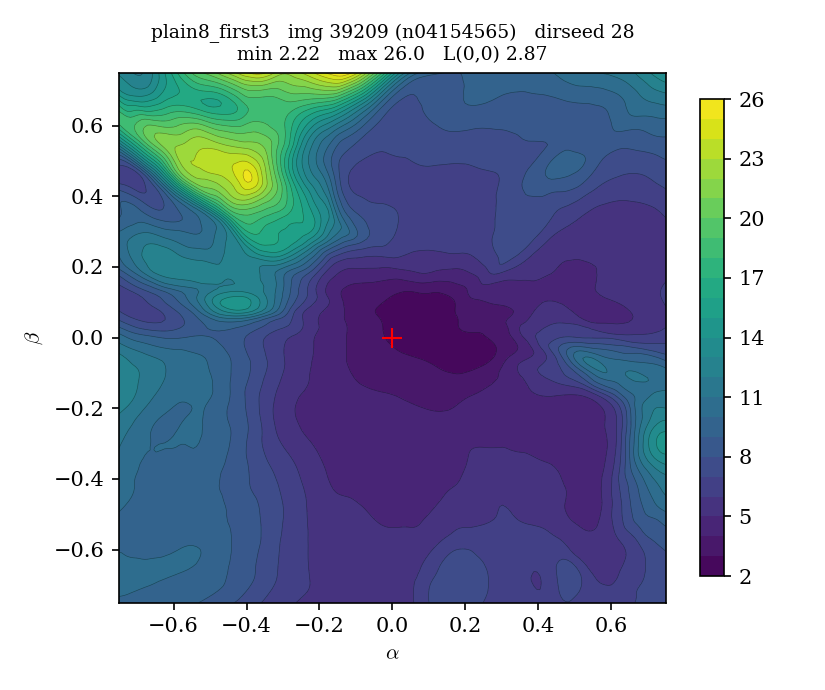

plain8:  50%|██████████████████▌                  | 1/2 [00:10<00:10, 10.37s/it]

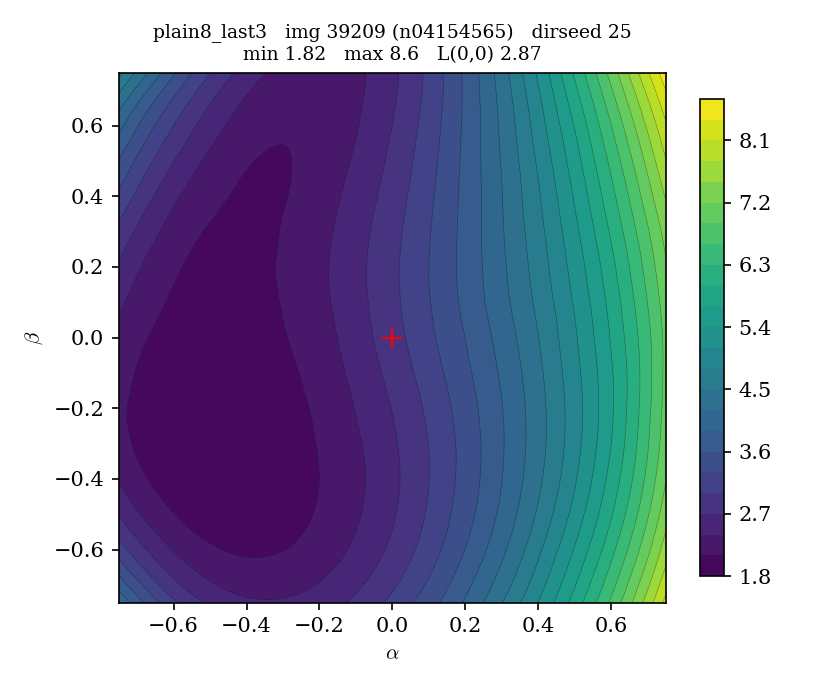

plain26:   0%|                                            | 0/1 [00:00<?, ?it/s]

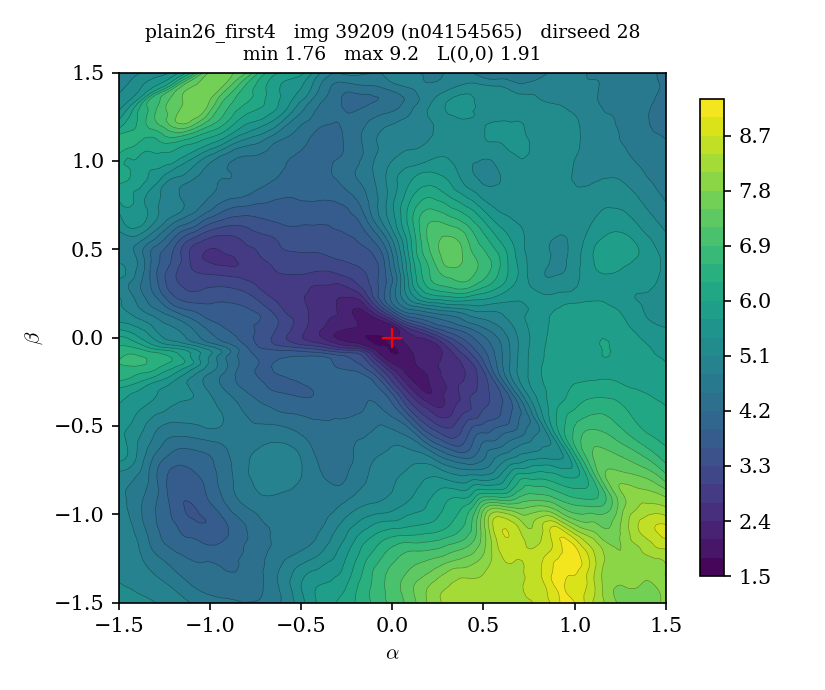

plain74:   0%|                                            | 0/2 [00:00<?, ?it/s]

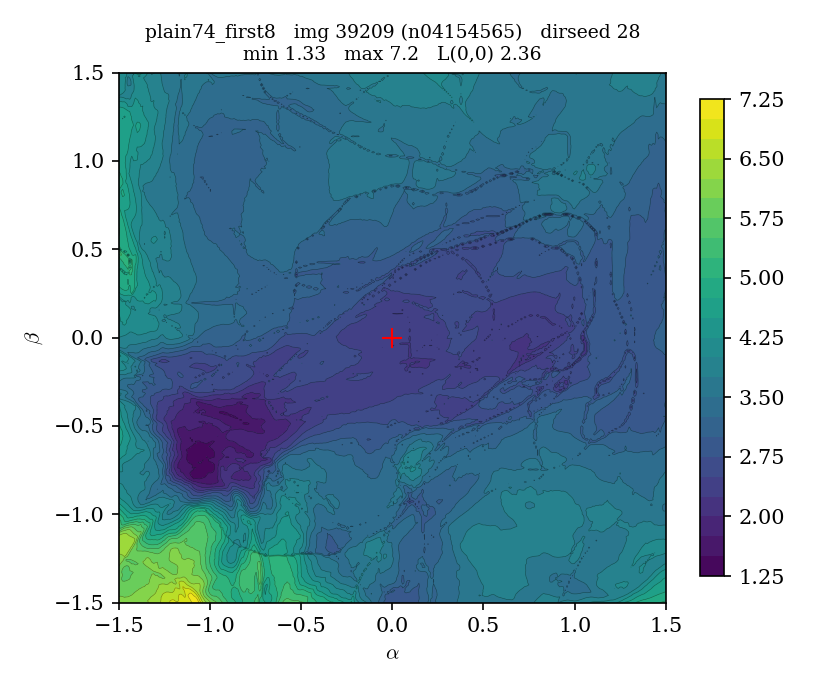

plain74:  50%|█████████████████▌                 | 1/2 [03:52<03:52, 232.89s/it]

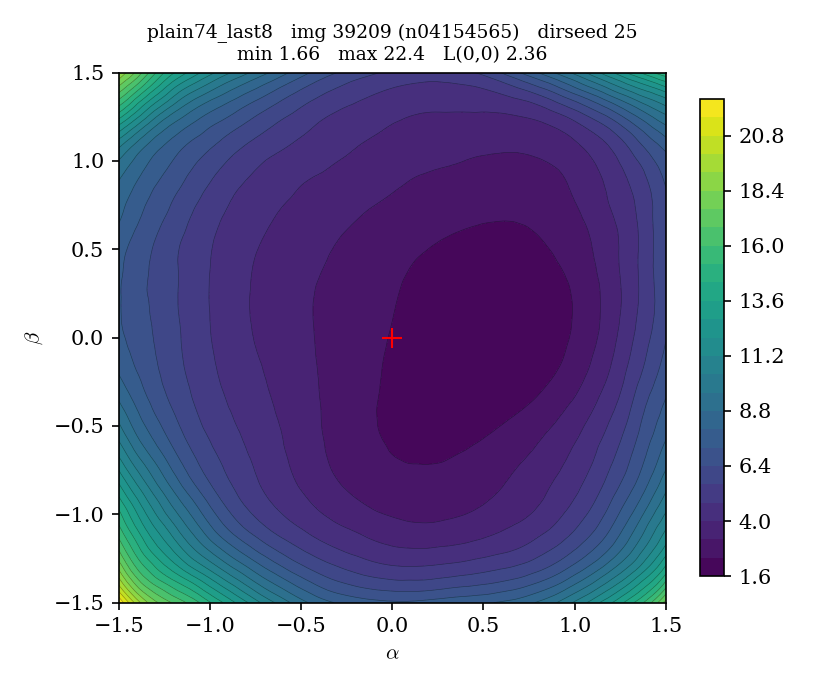

resnet74:   0%|                                           | 0/2 [00:00<?, ?it/s]

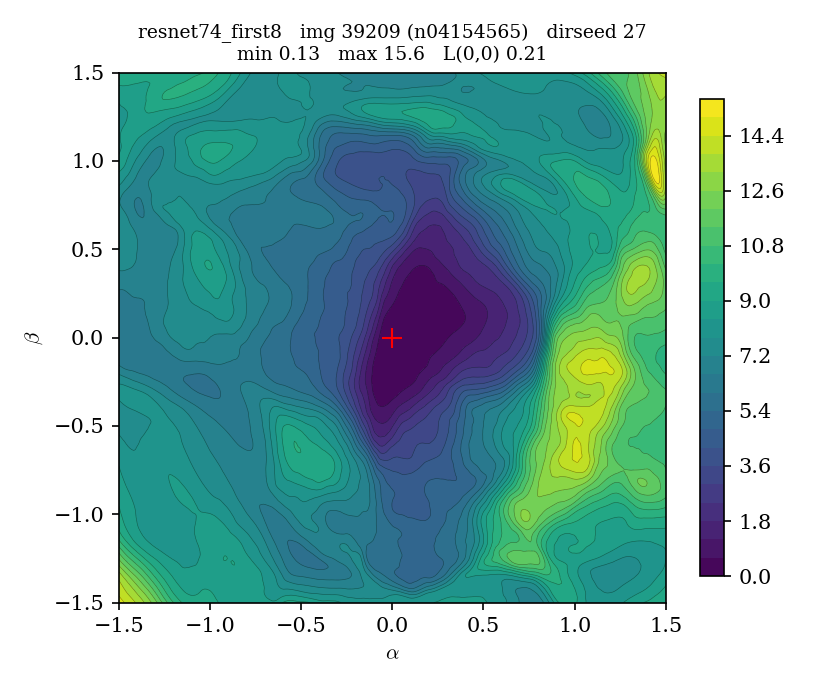

resnet74:  50%|█████████████████                 | 1/2 [04:01<04:01, 241.84s/it]

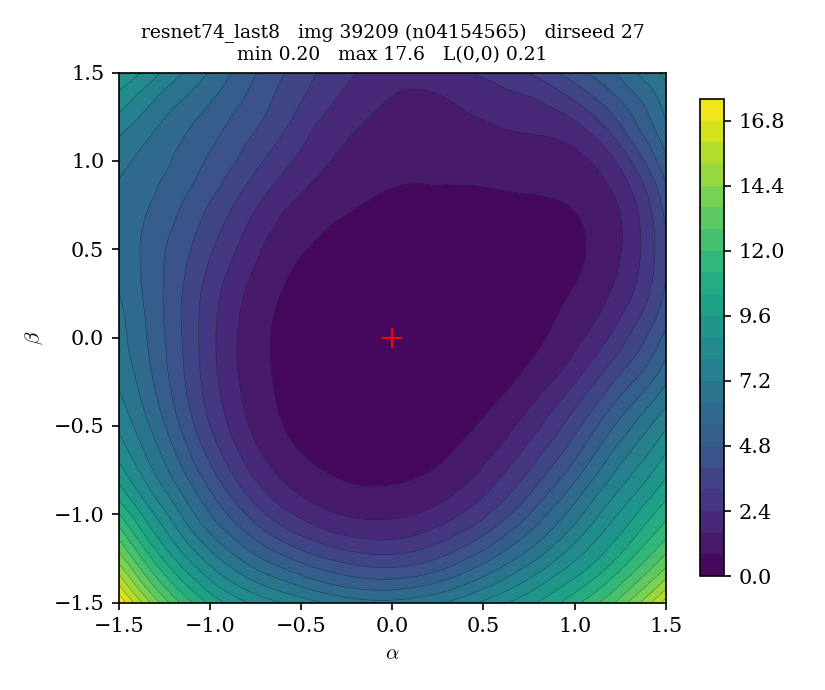

resnet74: 100%|██████████████████████████████████| 2/2 [08:48<00:00, 264.49s/it]


done -> /home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P33_landscapes/hires_option2


In [35]:
# ---- render favorites; each checkpoint is loaded once ----
fav_by_model = {}
for f in FAVORITES:
    fav_by_model.setdefault(LANDSCAPES[f["cfg"]][0], []).append(f)

for mn, favs in fav_by_model.items():
    model = load_model(mn)
    for f in tqdm(favs, desc=mn):
        cfg, idxs = f["cfg"], LANDSCAPES[f["cfg"]][1]
        grid, ext = f.get("grid", GRID_HIGH), f.get("extent", EXTENT)
        run_landscape(model, mn, cfg, idxs, f["img_idx"], f["dir_seed"], grid, HIRES_OUT, ext)
        show(cfg, f["img_idx"], f["dir_seed"], grid, HIRES_OUT, ext)
    del model; gc.collect(); torch.cuda.empty_cache()
print("done ->", HIRES_OUT)


In [36]:
#Yolo run lol
FAVORITES = [
    dict(cfg="plain8_first3",    img_idx=39209, dir_seed=28, grid=192, extent=0.75,  loss_cap=256),
    dict(cfg="plain8_last3",     img_idx=39209, dir_seed=25, grid=192, extent=0.75,  loss_cap=256),
    dict(cfg="plain26_first4",   img_idx=39209, dir_seed=28, grid=192, extent=1.5,  loss_cap=256),
    dict(cfg="plain74_first8",    img_idx=39209, dir_seed=28, grid=400, extent=2.5,  loss_cap=256),
    dict(cfg="resnet74_first8",    img_idx=39209, dir_seed=27, grid=400, extent=2.5,  loss_cap=256),
    dict(cfg="plain74_last8",    img_idx=39209, dir_seed=25, grid=400, extent=2.5,  loss_cap=256),
    dict(cfg="resnet74_last8",    img_idx=39209, dir_seed=27, grid=400, extent=2.5,  loss_cap=256),
]
HIRES_OUT = OUT / "hires_option3"


plain8:   0%|                                             | 0/2 [00:00<?, ?it/s]

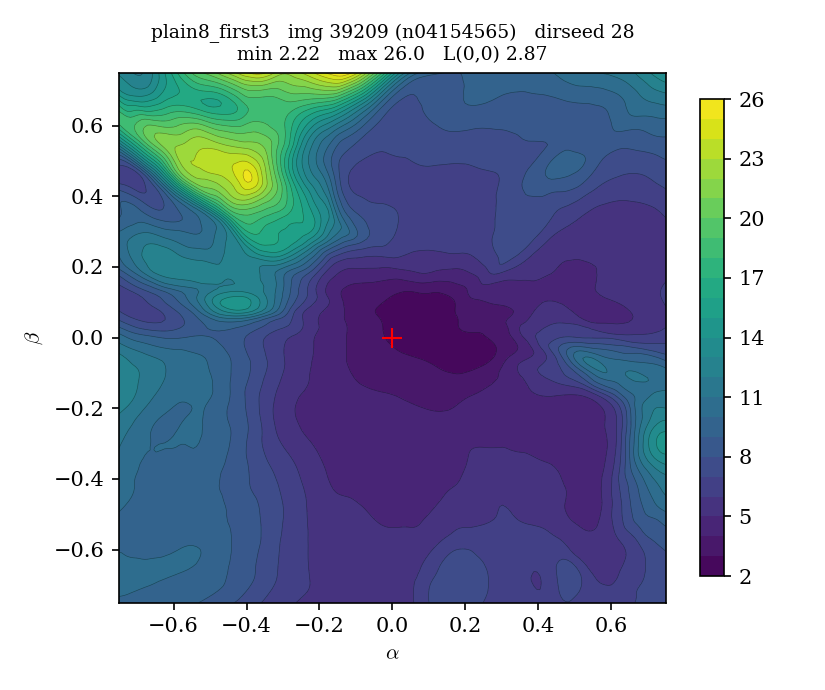

plain8:  50%|██████████████████▌                  | 1/2 [00:10<00:10, 10.06s/it]

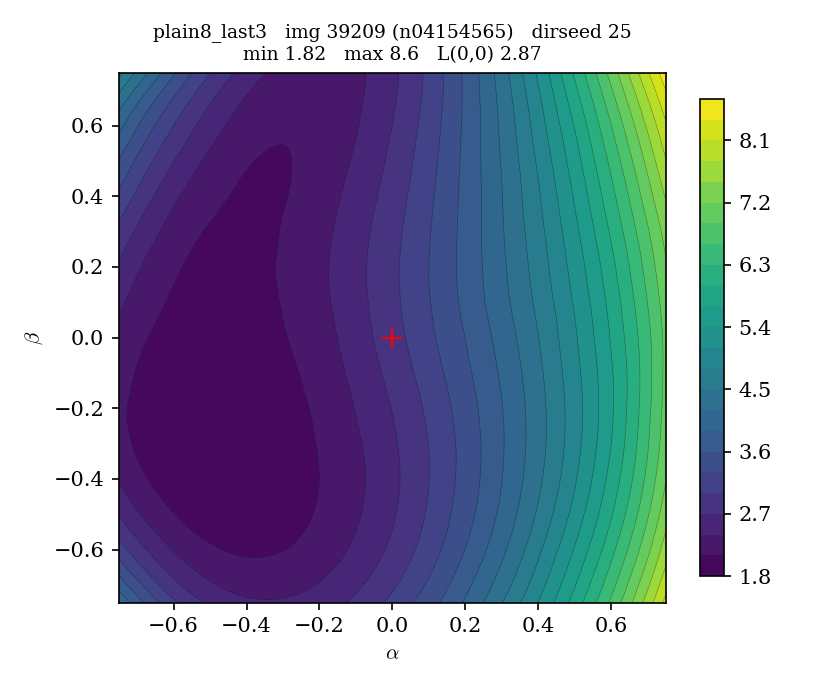

plain26:   0%|                                            | 0/1 [00:00<?, ?it/s]

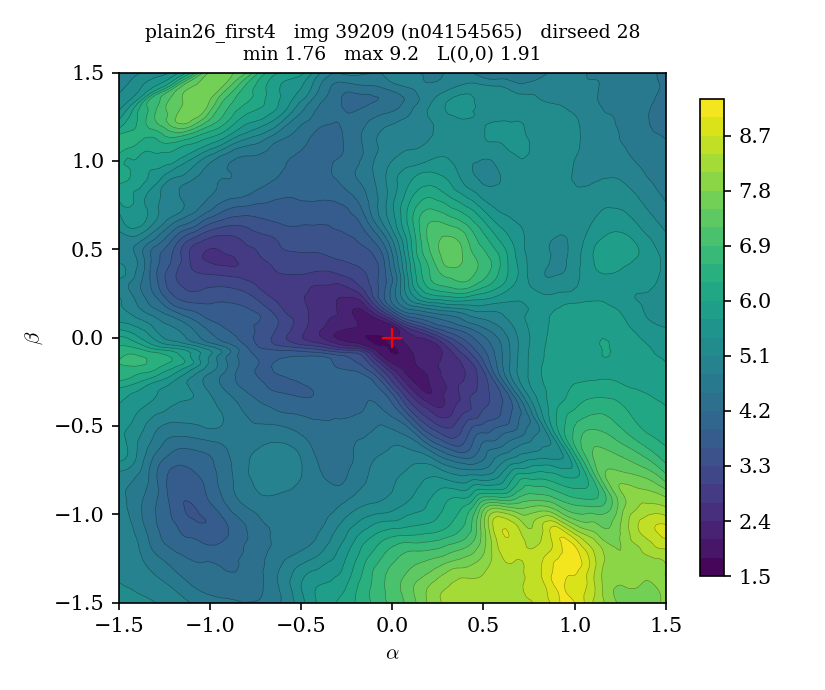

plain74:   0%|                                            | 0/2 [00:00<?, ?it/s]

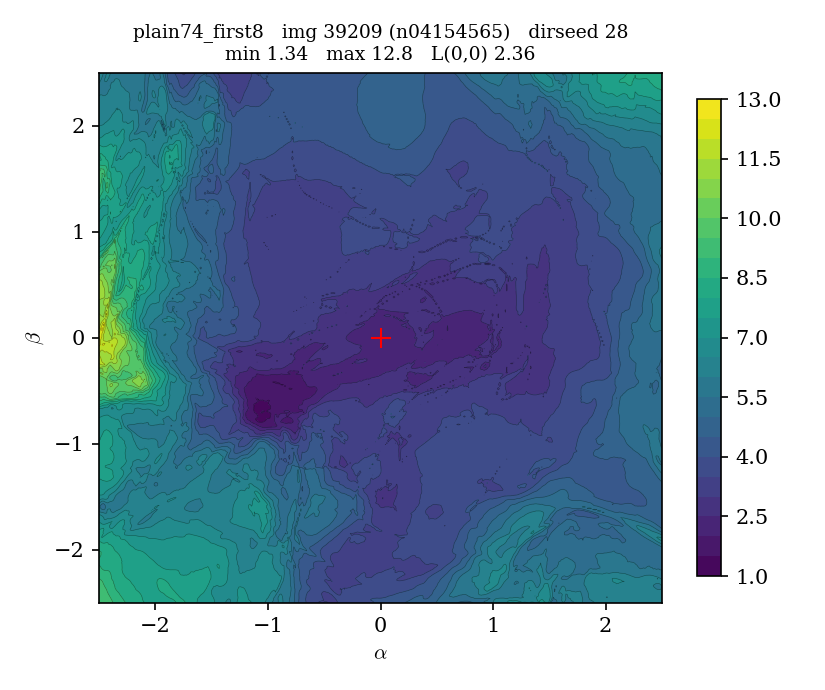

plain74:  50%|█████████████████▌                 | 1/2 [06:54<06:54, 414.36s/it]

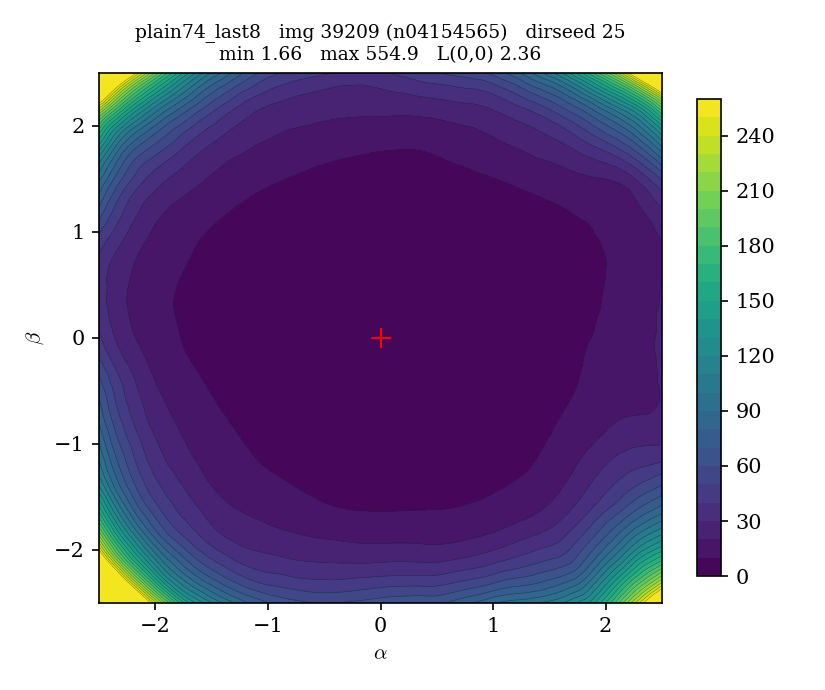

resnet74:   0%|                                           | 0/2 [00:00<?, ?it/s]

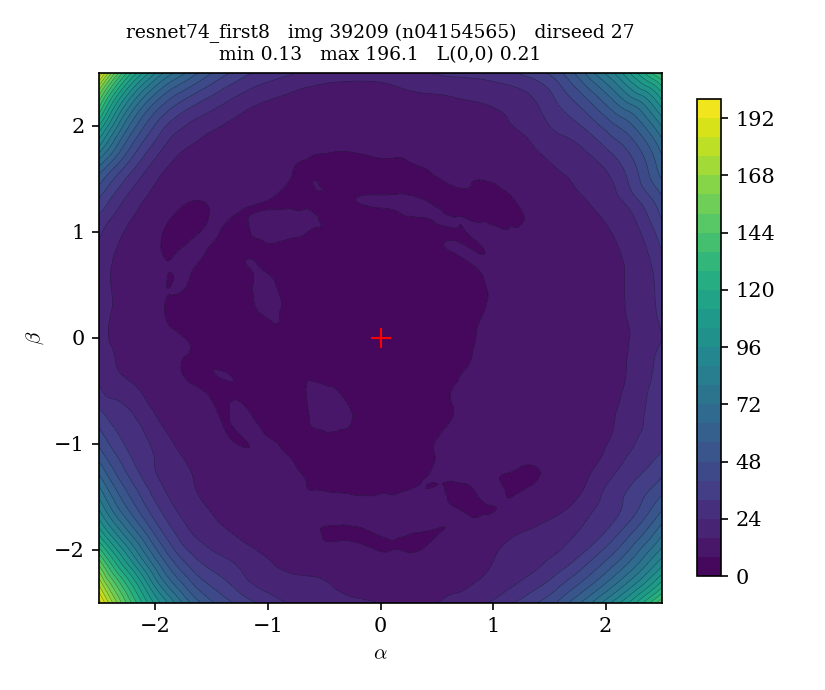

resnet74:  50%|█████████████████                 | 1/2 [07:12<07:12, 432.08s/it]

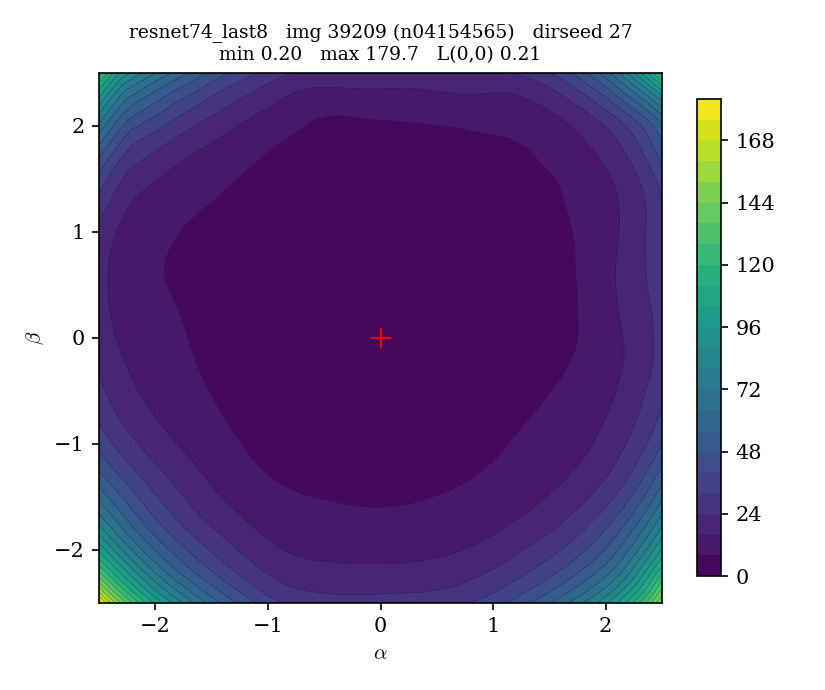

resnet74: 100%|██████████████████████████████████| 2/2 [15:40<00:00, 470.45s/it]


done -> /home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/P33_landscapes/hires_option3


In [37]:
# ---- render favorites; each checkpoint is loaded once ----
fav_by_model = {}
for f in FAVORITES:
    fav_by_model.setdefault(LANDSCAPES[f["cfg"]][0], []).append(f)

for mn, favs in fav_by_model.items():
    model = load_model(mn)
    for f in tqdm(favs, desc=mn):
        cfg, idxs = f["cfg"], LANDSCAPES[f["cfg"]][1]
        grid, ext = f.get("grid", GRID_HIGH), f.get("extent", EXTENT)
        run_landscape(model, mn, cfg, idxs, f["img_idx"], f["dir_seed"], grid, HIRES_OUT, ext)
        show(cfg, f["img_idx"], f["dir_seed"], grid, HIRES_OUT, ext)
    del model; gc.collect(); torch.cuda.empty_cache()
print("done ->", HIRES_OUT)
